[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pmRaul/DA-Python/blob/main/08_NumPy_Arrays/08_NumPy_Arrays.ipynb)

# 🐍 Array-Oriented Programming 📊

In the [previous post](https://github.com/pmRaul/DA-Python/blob/main/07_NumPy/07_NumPy.md) 🌟, we introduced `NumPy` and some of its main features. The **biggest advantage** of using `NumPy` is its **superior speed** compared to standard `Python` when dealing with numerical data structures like vectors, matrices, or tensors. This improvement comes partly from the ability to perform many data processing tasks using concise expressions applied directly to `arrays`, which would otherwise require **loops**. 

The practice of replacing loops with array-based expressions is known as **vectorization**, which, along with **broadcasting**, forms the foundation of **Array-Oriented Programming** (*AOP*). In this post, we'll explain these concepts to help you maximize the performance of `NumPy` and achieve significant speedups in your `Python` code. 🚀

## ⚡ Vectorization

Imagine you want to evaluate the function $z = \sqrt{x^2 + y^2 }$ over a regular grid of values. A simple way to perform this operation is as follows:

In [1]:
import numpy as np
import math

def slow(n=1000):
    x = np.linspace(-1, 1, n)
    y = np.linspace(-1, 1, n)
    z = np.empty((n, n))

    for i, _y in enumerate(y):
        for j, _x in enumerate(x):
            z[i, j] = math.sqrt(_x**2 + _y**2)
            
    return x, y, z

%time x, y, z = slow()

CPU times: total: 422 ms
Wall time: 411 ms


*🕒 Wall time: 909 ms*

We can visualize this function using `Matplotlib` 🎨 (a library we'll discuss in detail in a future post).

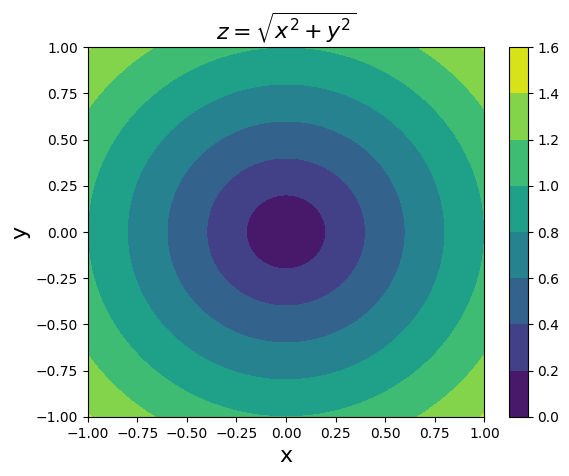

In [3]:
import matplotlib.pyplot as plt

def plot(x, y, z):
    plt.contourf(x, y, z)
    plt.colorbar()
    plt.xlabel("x", fontsize="16")
    plt.ylabel("y", fontsize="16")
    plt.title("$z = \\sqrt{x^2 + y^2 }$", fontsize="16")
    plt.show()
    
plot(x, y, z)

As you can see in the `function` implementation, evaluating the expression requires two `for` loops to iterate over all `x` and `y` values and calculate the result. This is an **inefficient implementation** that can be accelerated by applying **vectorization**, which replaces loops with array-based expressions.

In [4]:
def fast(n=1000):
    p = np.linspace(-1, 1, n)
    x, y = np.meshgrid(p, p)
    z = np.sqrt(x**2 + y**2)
    return x, y, z

%time x, y, z = fast()

CPU times: total: 0 ns
Wall time: 8.04 ms


*🕒 Wall time: 19 ms*

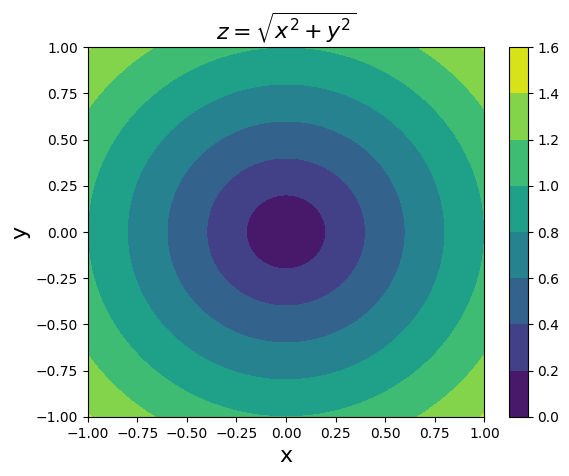

In [5]:
plot(x, y, z)

The result is the same but **50 times faster**! 🎉 This is thanks to **vectorization**. `NumPy` provides numerous functions that we can leverage to speed up our calculations.

> 💡 **Tip:** Always look for ways to use `NumPy`'s built-in functions to replace explicit loops for better performance.

## 🔍 Universal Functions

These functions perform element-wise operations on an `array`. In the previous example, we saw one: `np.sqrt`, which calculates the square root of all elements in an `array` without the need for any loops. Here are some more examples:

In [7]:
a = np.array([[2.5, 3.1, 7], [10, 11, 12]])
a

array([[ 2.5,  3.1,  7. ],
       [10. , 11. , 12. ]])

In [8]:
for func in (np.abs, np.sqrt, np.exp, np.log, np.sign, np.ceil, np.modf, np.isnan, np.cos):
    print(f"\n{func.__name__}")
    print(func(a))


absolute
[[ 2.5  3.1  7. ]
 [10.  11.  12. ]]

sqrt
[[1.58113883 1.76068169 2.64575131]
 [3.16227766 3.31662479 3.46410162]]

exp
[[1.21824940e+01 2.21979513e+01 1.09663316e+03]
 [2.20264658e+04 5.98741417e+04 1.62754791e+05]]

log
[[0.91629073 1.13140211 1.94591015]
 [2.30258509 2.39789527 2.48490665]]

sign
[[1. 1. 1.]
 [1. 1. 1.]]

ceil
[[ 3.  4.  7.]
 [10. 11. 12.]]

modf
(array([[0.5, 0.1, 0. ],
       [0. , 0. , 0. ]]), array([[ 2.,  3.,  7.],
       [10., 11., 12.]]))

isnan
[[False False False]
 [False False False]]

cos
[[-0.80114362 -0.99913515  0.75390225]
 [-0.83907153  0.0044257   0.84385396]]


### 🧮 Statistical Functions

These functions allow us to compute statistical values over our `arrays`. Some examples include:

In [9]:
for func in (a.min, a.max, a.sum, a.prod, a.std, a.var):
    print(f"{func.__name__} = {func()}")

min = 2.5
max = 12.0
sum = 45.6
prod = 71610.0
std = 3.7260345319566395
var = 13.883333333333333


We can also specify the axis over which to compute these values:

In [10]:
# Calculate the mean value of each column

a.mean(axis=0)

array([6.25, 7.05, 9.5 ])

In [11]:
# Sum all values of each row

a.sum(axis=1)

array([12.6, 33. ])

## 🌐 Broadcasting

**Broadcasting** is the second key feature (after **vectorization**) that gives `NumPy` its versatility and power when performing operations on `arrays`. Generally, when `NumPy` expects `arrays` of the same shape but finds that they don't match, it applies broadcasting rules. Let's explore these rules in detail.

### 📏 First Rule

If two `arrays` don't have the same rank (number of dimensions), a dimension of `1` is added to the beginning of the `array` with the smaller rank until they match.

> 💡 **Note:** The rank of an `array` is the same as its number of dimensions.

Let's create a 3-dimensional `array`:

In [12]:
a = np.arange(5).reshape(1, 1, 5)
a

array([[[0, 1, 2, 3, 4]]])

In [13]:
a.shape

(1, 1, 5)

Now, let's add another 1-dimensional `array`:

In [14]:
b = np.arange(5)
b

array([0, 1, 2, 3, 4])

In [15]:
b.shape

(5,)

When we try to add these two `arrays`, `NumPy` doesn't raise any errors. Instead, it applies the **first broadcasting rule**, adding extra dimensions to `b` to make its shape `(1, 1, 5)` and then performs the addition. This is the same rule that allows adding a scalar to a vector or matrix.

In [16]:
a + b

array([[[0, 2, 4, 6, 8]]])

In [17]:
1 + a

array([[[1, 2, 3, 4, 5]]])

### 📐 Second Rule

If an `array` has a `1` in a particular dimension, it behaves as if it has the length of the `array` with the maximum length in that dimension. This means the value in this dimension is repeated until it matches the length. For example:

In [18]:
a = np.arange(6).reshape(2, 3)
a

array([[0, 1, 2],
       [3, 4, 5]])

In [19]:
a.shape

(2, 3)

In [20]:
b = np.array([[100], [200]])
b

array([[100],
       [200]])

In [21]:
b.shape

(2, 1)

When we add these two matrices, `NumPy` repeats the values in `b` to create three identical columns, allowing the addition:

In [22]:
a + b

array([[100, 101, 102],
       [203, 204, 205]])

Broadcasting rules can be combined. For example:

In [23]:
c = np.array([100, 200, 300])
c.shape

(3,)

In [24]:
a + c

array([[100, 201, 302],
       [103, 204, 305]])

Here, `NumPy` adds an extra dimension to `c` to make its shape `(1, 3)` and then repeats the values to create two rows, allowing the addition.

### 📏 Third Rule

After applying the first two rules, the dimensions of the `arrays` must match. If they don't, the operation cannot be performed.

In [25]:
a + [1, 2]

ValueError: operands could not be broadcast together with shapes (2,3) (2,) 

Here's a visual example of these rules applied to various `arrays`:

![Broadcasting](https://jakevdp.github.io/PythonDataScienceHandbook/figures/02.05-broadcasting.png)

These rules apply to virtually all `NumPy` operations that involve two `arrays`, not just arithmetic operations. Being able to leverage **broadcasting** effectively will help you implement fast and efficient algorithms, which is essential for data analysis and building Artificial Intelligence models. 🤖

## 🔄 Reshaping and Slicing Arrays

Understanding how to manipulate the shape and contents of `arrays` is crucial for effective data analysis and manipulation.

### 🌀 Reshaping Arrays

`NumPy` allows you to change the shape of an `array` without changing its data. This is useful when preparing data for different operations or algorithms.

In [26]:
# Create a 1D array
arr = np.arange(12)
print("Original array:", arr)

# Reshape to 3x4
matrix = arr.reshape((3, 4))
print("Reshaped to 3x4:\n", matrix)

# Reshape to 2x2x3
tensor = arr.reshape((2, 2, 3))
print("Reshaped to 2x2x3:\n", tensor)

Original array: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Reshaped to 3x4:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Reshaped to 2x2x3:
 [[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 🔍 Slicing Arrays

Slicing allows you to extract subsets of data from an `array`.

In [27]:
# Create a 2D array
a = np.arange(16).reshape((4, 4))
print("Original array:\n", a)

# Slice rows 1 and 2
print("Rows 1 and 2:\n", a[1:3, :])

# Slice columns 2 and 3
print("Columns 2 and 3:\n", a[:, 2:4])

# Extract a submatrix
print("Submatrix:\n", a[1:3, 1:3])

Original array:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
Rows 1 and 2:
 [[ 4  5  6  7]
 [ 8  9 10 11]]
Columns 2 and 3:
 [[ 2  3]
 [ 6  7]
 [10 11]
 [14 15]]
Submatrix:
 [[ 5  6]
 [ 9 10]]


### 🎯 Advanced Indexing

`NumPy` provides advanced indexing capabilities, such as boolean masking and fancy indexing.

In [28]:
# Create an array
a = np.arange(10)

# Boolean masking
mask = a > 5
print("Elements greater than 5:", a[mask])

# Fancy indexing with a list of indices
indices = [1, 3, 5, 7]
print("Elements at indices 1,3,5,7:", a[indices])

Elements greater than 5: [6 7 8 9]
Elements at indices 1,3,5,7: [1 3 5 7]


## 📏 Shape Manipulation Functions

Changing the shape of an `array` can be done using various functions provided by `NumPy`.

- **`reshape`**: Changes the shape of an `array` without changing its data.
- **`squeeze`**: Removes single-dimensional entries from the shape.
- **`expand_dims`**: Adds a new axis to an `array`.

In [29]:
# Create an array with shape (1, 3, 1)
a = np.array([[[1], [2], [3]]])
print("Original shape:", a.shape)

# Squeeze to remove single dimensions
squeezed = np.squeeze(a)
print("Squeezed shape:", squeezed.shape)

# Expand dims to add a new axis
expanded = np.expand_dims(squeezed, axis=0)
print("Expanded shape:", expanded.shape)

Original shape: (1, 3, 1)
Squeezed shape: (3,)
Expanded shape: (1, 3)


## 🛠️ Exercises 🛠️📚

### Exercise 1: Creating and Inspecting Arrays

**Task:**

1. Create a 2D NumPy array with shape `(4, 5)` filled with zeros.
2. Change the data type of the array to `int32`.
3. Print the shape, data type, and size of the array.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create a 2D array of zeros with shape (4, 5)
array = np.zeros((4, 5), dtype=np.int32)

# Print properties
print("Shape:", array.shape)       # Output: Shape: (4, 5)
print("Data type:", array.dtype)   # Output: Data type: int32
print("Size:", array.size)         # Output: Size: 20
```
</details>

### Exercise 2: Array Operations and Broadcasting

**Task:**

1. Create a 1D NumPy array `a` with values `[10, 20, 30, 40, 50]`.
2. Create a scalar `b` with value `5`.
3. Perform the following operations and print the results:
   - Add `b` to `a`.
   - Multiply `a` by `b`.
   - Subtract `b` from `a`.
   - Divide `a` by `b`.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create array and scalar
a = np.array([10, 20, 30, 40, 50])
b = 5

# Perform operations
print("a + b:", a + b)       # Output: [15 25 35 45 55]
print("a * b:", a * b)       # Output: [ 50 100 150 200 250]
print("a - b:", a - b)       # Output: [ 5 15 25 35 45]
print("a / b:", a / b)       # Output: [2. 4. 6. 8. 10.]
```
</details>

### Exercise 3: Reshaping and Transposing Arrays

**Task:**

1. Create a NumPy array with values from `0` to `11`.
2. Reshape the array into a `3x4` matrix.
3. Transpose the matrix.
4. Print both the reshaped matrix and its transpose.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create array
array = np.arange(12)

# Reshape to 3x4 matrix
matrix = array.reshape((3, 4))
print("Reshaped Matrix:\n", matrix)
# Output:
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

# Transpose the matrix
transpose = matrix.T
print("Transposed Matrix:\n", transpose)
# Output:
# [[ 0  4  8]
#  [ 1  5  9]
#  [ 2  6 10]
#  [ 3  7 11]]
```
</details>

### Exercise 4: Indexing and Boolean Masking

**Task:**

1. Create a NumPy array `data` with values from `1` to `20`.
2. Reshape `data` into a `4x5` matrix.
3. Use boolean masking to extract all elements greater than `10`.
4. Print the extracted elements.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create and reshape array
data = np.arange(1, 21)
matrix = data.reshape((4, 5))
print("Original Matrix:\n", matrix)
# Output:
# [[ 1  2  3  4  5]
#  [ 6  7  8  9 10]
#  [11 12 13 14 15]
#  [16 17 18 19 20]]

# Boolean masking for elements greater than 10
filtered = matrix[matrix > 10]
print("Elements greater than 10:", filtered)
# Output: [11 12 13 14 15 16 17 18 19 20]
```
</details>

### Exercise 5: Saving and Loading Arrays

**Task:**

1. Create a NumPy array `arr` with random values of shape `(3, 3)`.
2. Save the array to a file named `random_array.npy`.
3. Load the array from the file and print it to verify.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create a random array
arr = np.random.rand(3, 3)
print("Original Array:\n", arr)

# Save the array to a file
np.save('random_array.npy', arr)

# Load the array from the file
loaded_arr = np.load('random_array.npy')
print("Loaded Array:\n", loaded_arr)
```
</details>

### Exercise 6: Linear Algebra Operations

**Task:**

1. Create two `2x2` matrices `A` and `B` with arbitrary integer values.
2. Compute the matrix product of `A` and `B`.
3. Calculate the inverse of matrix `A` (if it exists).
4. Print all results.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create matrices
A = np.array([[2, 3], [1, 4]])
B = np.array([[5, 6], [7, 8]])

print("Matrix A:\n", A)
print("Matrix B:\n", B)

# Matrix product
product = np.dot(A, B)
print("Product of A and B:\n", product)
# Output:
# [[29 30]
#  [33 38]]

# Inverse of A
inverse_A = np.linalg.inv(A)
print("Inverse of A:\n", inverse_A)
# Output:
# [[ 0.8 -0.6]
#  [-0.2  0.4]]
```
</details>

### Exercise 7: Statistical Analysis

**Task:**

1. Generate a NumPy array `scores` with 1000 random values following a normal distribution (mean=50, std=10).
2. Calculate and print the mean, median, standard deviation, and the 90th percentile of the `scores`.
3. Identify and print how many scores are above the 90th percentile.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Generate scores
scores = np.random.normal(loc=50, scale=10, size=1000)

# Calculate statistics
mean = np.mean(scores)
median = np.median(scores)
std_dev = np.std(scores)
percentile_90 = np.percentile(scores, 90)

print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"90th Percentile: {percentile_90:.2f}")

# Count scores above the 90th percentile
above_90 = np.sum(scores > percentile_90)
print(f"Number of scores above the 90th percentile: {above_90}")
```
</details>

### Exercise 8: Manipulating Multi-dimensional Arrays

**Task:**

1. Create a 3D NumPy array `tensor` with shape `(2, 3, 4)` filled with sequential integers starting from 0.
2. Extract a `2x4` matrix by selecting the first two layers and all rows of the second dimension.
3. Print the extracted matrix.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create 3D tensor
tensor = np.arange(24).reshape((2, 3, 4))
print("Original Tensor:\n", tensor)
# Output:
# [[[ 0  1  2  3]
#   [ 4  5  6  7]
#   [ 8  9 10 11]]
#
#  [[12 13 14 15]
#   [16 17 18 19]
#   [20 21 22 23]]]

# Extract a 2x4 matrix from the first two layers and all rows of the second dimension
extracted = tensor[:, 1, :]
print("Extracted Matrix:\n", extracted)
# Output:
# [[ 4  5  6  7]
#  [16 17 18 19]]
```
</details>

### Exercise 9: Broadcasting with Different Shapes

**Task:**

1. Create a 2D NumPy array `A` with shape `(3, 1)` containing values `[[1], [2], [3]]`.
2. Create a 1D NumPy array `B` with values `[4, 5, 6, 7]`.
3. Add arrays `A` and `B` using broadcasting and print the result.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create arrays
A = np.array([[1], [2], [3]])  # Shape (3,1)
B = np.array([4, 5, 6, 7])     # Shape (4,)

# Add using broadcasting
result = A + B
print("Result of A + B:\n", result)
# Output:
# [[5 6 7 8]
#  [6 7 8 9]
#  [7 8 9 10]]
```
</details>

### Exercise 10: Reshaping and Flattening Arrays

**Task:**

1. Create a 3D NumPy array `C` with shape `(2, 2, 3)` containing values from `0` to `11`.
2. Reshape `C` into a 2D array with shape `(4, 3)`.
3. Flatten the reshaped array back into a 1D array.
4. Print all three arrays to verify the transformations.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create 3D array
C = np.arange(12).reshape((2, 2, 3))
print("Original 3D Array C:\n", C)

# Reshape to 2D array (4,3)
reshaped = C.reshape((4, 3))
print("Reshaped to 4x3:\n", reshaped)

# Flatten back to 1D array
flattened = reshaped.flatten()
print("Flattened Array:\n", flattened)
```
</details>

### Exercise 11: Stacking and Splitting Arrays

**Task:**

1. Create two 1D NumPy arrays `x` and `y` with values `[1, 2, 3]` and `[4, 5, 6]` respectively.
2. Stack `x` and `y` vertically to form a 2x3 matrix.
3. Split the resulting matrix back into two separate arrays.
4. Print all results to verify.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create arrays
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

# Stack vertically
stacked = np.vstack((x, y))
print("Vertically Stacked Array:\n", stacked)
# Output:
# [[1 2 3]
#  [4 5 6]]

# Split back into separate arrays
split_arrays = np.split(stacked, 2, axis=0)
print("First Array after Split:\n", split_arrays[0])
print("Second Array after Split:\n", split_arrays[1])
# Output:
# [[1 2 3]]
# [[4 5 6]]
```
</details>

### Exercise 12: Fancy Indexing with Multiple Indices

**Task:**

1. Create a 2D NumPy array `D` with shape `(4, 4)` containing values from `0` to `15`.
2. Use fancy indexing to extract the elements at positions `(0,0)`, `(1,1)`, `(2,2)`, and `(3,3)`.
3. Print the extracted elements.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create 2D array
D = np.arange(16).reshape((4, 4))
print("Original Array D:\n", D)
# Output:
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]
#  [12 13 14 15]]

# Fancy indexing
rows = [0, 1, 2, 3]
cols = [0, 1, 2, 3]
elements = D[rows, cols]
print("Extracted Elements:", elements)
# Output: [ 0  5 10 15]
```
</details>

### Exercise 13: Conditional Operations with Arrays

**Task:**

1. Create a NumPy array `E` with values from `-5` to `5`.
2. Replace all negative values in `E` with `0` using conditional operations.
3. Print the modified array.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create array
E = np.arange(-5, 6)
print("Original Array E:", E)
# Output: [-5 -4 -3 -2 -1  0  1  2  3  4  5]

# Replace negative values with 0
E[E < 0] = 0
print("Modified Array E:", E)
# Output: [0 0 0 0 0 0 1 2 3 4 5]
```
</details>

### Exercise 14: Aggregating Data with Axis Parameter

**Task:**

1. Create a 3D NumPy array `F` with shape `(2, 3, 4)` filled with random integers between `0` and `10`.
2. Compute the sum of elements along the first axis (`axis=0`).
3. Compute the sum of elements along the second axis (`axis=1`).
4. Compute the sum of elements along the third axis (`axis=2`).
5. Print all results.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create 3D array with random integers
F = np.random.randint(0, 11, size=(2, 3, 4))
print("Original Array F:\n", F)

# Sum along the first axis (axis=0)
sum_axis0 = F.sum(axis=0)
print("Sum along axis=0:\n", sum_axis0)

# Sum along the second axis (axis=1)
sum_axis1 = F.sum(axis=1)
print("Sum along axis=1:\n", sum_axis1)

# Sum along the third axis (axis=2)
sum_axis2 = F.sum(axis=2)
print("Sum along axis=2:\n", sum_axis2)
```
</details>

### Exercise 15: Using `np.where` for Conditional Selection

**Task:**

1. Create a NumPy array `G` with values from `0` to `9`.
2. Use `np.where` to create a new array where each element is:
   - `'Even'` if the element in `G` is even.
   - `'Odd'` if the element in `G` is odd.
3. Print the resulting array.

<details>
<summary>Solution</summary>

```python
import numpy as np

# Create array
G = np.arange(10)
print("Original Array G:", G)
# Output: [0 1 2 3 4 5 6 7 8 9]

# Use np.where for conditional selection
result = np.where(G % 2 == 0, 'Even', 'Odd')
print("Resulting Array:", result)
# Output: ['Even' 'Odd' 'Even' 'Odd' 'Even' 'Odd' 'Even' 'Odd' 'Even' 'Odd']
```
</details>

---